In [1]:
# Imports
import numpy as np
from scipy.linalg import eig
import matplotlib.pyplot as plt


In [126]:
# Array of r values
R = 0.01
N = 50    # keep same domain extent r_max = 50
dr = R/N
r_values = np.arange(1, N+1) * dr + 1.

# Defining constants
U = 1
H = 1
kappa = np.ones(N) 
v_parallel = 1

# Equilibrium pressure and potential
L_p = 0.1
p_0 = 1. * np.exp(-(r_values-r_values[0])/L_p)

L_phi = 0.1
phi_0  = 0. * np.exp(-(r_values-r_values[0])/L_phi)

# Which mode
m = 1

# Matrix Helper Functions

In [127]:
def create_first_derivative_matrix(N_, dr_):
    matrix = np.zeros((N_,N_))

    for i in range(1, N_-1, 1):
        matrix[i][i+1] = 1 
        matrix[i][i-1] = -1

    matrix[0][0] = -3 
    matrix[0][1] = 4
    matrix[0][2] = -1

    matrix[N_-1][N_-3] = 1 
    matrix[N_-1][N_-2] = -4
    matrix[N_-1][N_-1] = 3

    return matrix / (2 * dr_)

def create_second_derivative_matrix(N_, dr_):
    matrix = np.zeros((N_,N_))

    for i in range(1, N_-1, 1):
        matrix[i][i+1] = 1 
        matrix[i][i] = -2
        matrix[i][i-1] = 1

    matrix[0][0] = 2
    matrix[0][1] = -5
    matrix[0][2] = 4
    matrix[0][3] = -1

    matrix[N_-1][N_-4] = -1
    matrix[N_-1][N_-3] = 4
    matrix[N_-1][N_-2] = -5
    matrix[N_-1][N_-1] = 2

    return matrix / (dr_ ** 2)

def create_third_derivative_matrix(N_, dr_):
    matrix = np.zeros((N_,N_))

    for i in range(2, N_-2, 1):
        matrix[i][i-2] = -1
        matrix[i][i-1] = 2
        matrix[i][i+1] = -2
        matrix[i][i+2] = 1

    matrix[0][0] = -5
    matrix[0][1] = 18
    matrix[0][2] = -24
    matrix[0][3] = 14
    matrix[0][4] = -3

    matrix[N_-1][N_-1] = 5
    matrix[N_-1][N_-2] = -18
    matrix[N_-1][N_-3] = 24
    matrix[N_-1][N_-4] = -14
    matrix[N_-1][N_-5] = 3

    matrix[1][0] = -3
    matrix[1][1] = 10
    matrix[1][2] = -12
    matrix[1][3] = 6
    matrix[1][4] = -1

    matrix[N_-2][N_-1] = 3
    matrix[N_-2][N_-2] = -10
    matrix[N_-2][N_-3] = 12
    matrix[N_-2][N_-4] = -6
    matrix[N_-2][N_-5] = 1

    return (matrix / (2 * (dr_ ** 3)))

def create_m_laplacian(N_, dr_, m_, r_values_):
    D1 = create_first_derivative_matrix(N_, dr_)
    D2 = create_second_derivative_matrix(N_, dr_)

    return (
        D2
        + np.diag(1 / r_values_) @ D1
        - np.diag(m_**2 / (r_values_**2))
    )

def enforce_bc(A_, B_, N_):
    A_[N_-1][:] = 0
    B_[N_-1][:] = 0
    B_[N_-1][N_-1] = 1

    B_[0][:] = 0
    B_[0][0] = 1
    A_[0][:] = 0

    B_[N_][:] = 0
    B_[N_][N_] = 1
    A_[N_][:] = 0

    return A_, B_

# NOTE: here our operator definitions are a little different because we are discarding source terms, 
# FLR terms, line tying terms, and all parallel/perpendicular loss terms
def create_A_and_B(N_, dr_, m_, r_values_, phi_0_, p_0_, v_parallel_, H_, k_, U_):
    D1 = create_first_derivative_matrix(N_, dr_)
    D2 = create_second_derivative_matrix(N_, dr_)
    D3 = create_third_derivative_matrix(N_, dr_)
    Dm = create_m_laplacian(N_, dr_, m_, r_values_)

    diag_div_r = np.diag(1 / r_values_)

    omega_0_diag = diag_div_r @ np.diag(D1 @ phi_0_)
    D_phi_prime_diag = np.diag((D3 + diag_div_r @ D2 - np.diag(1 / (r_values_ ** 2)) @ D1) @ phi_0_)

    L11 = (-1j * m_ * omega_0_diag @ Dm 
        + 1j * m_ * diag_div_r @ D_phi_prime_diag)
    L12 = - 2j * m_ * np.diag(k_)
    L21 = 1j * m_ * np.diag(1 / r_values_) @ np.diag(D1 @ p_0_)
    L22 = - (1j * m_ * omega_0_diag)

    A = np.block([
        [Dm, np.zeros((N_,N_))],
        [np.zeros((N_,N_)), np.eye(N_)]
    ])

    B = np.block([
        [L11, L12],
        [L21, L22]
    ])

    A, B = enforce_bc(A, B, N_)

    return A, B

## Linear Stability Operator

The eigenvalue problem to be solved is:

$$
\gamma
\begin{pmatrix} \Delta_m & 0 \\ 0 & 1 \end{pmatrix}
\begin{pmatrix} \hat\varphi \\ \hat\rho \end{pmatrix}
=
\begin{pmatrix} \mathcal{L}_{11} & \mathcal{L}_{12} \\ \mathcal{L}_{21} & \mathcal{L}_{22} \end{pmatrix}
\begin{pmatrix} \hat\varphi \\ \hat\rho \end{pmatrix}.
$$

### Linear operators (expanded form)

$$
\mathcal{L}_{11}
  = -im\Omega_0 \Delta_m
    + \frac{im}{r}(\Delta\varphi_0)'
    - \frac{imU}{r}\left(P_0''\frac{\partial}{\partial r} + P_0'\,\frac{\partial^2}{\partial r^2}\right)
    + \frac{im^3 U}{r^3}\,P_0'
    + H
    - \nu_\parallel \Delta_m,
$$

$$
\mathcal{L}_{12}
  = \frac{imU}{r}\left(\varphi_0''' + \varphi_0''\,\frac{\partial}{\partial r}\right) - 2im\mathcal{K},
$$

$$
\mathcal{L}_{21} = \frac{im}{r}P_0'(r),
$$

$$
\mathcal{L}_{22} = -\nu_\parallel^P - im\Omega_0(r).
$$

where
$$\Omega_0(r) \equiv \frac{1}{r}\frac{\partial \varphi_0}{\partial r}, \quad \text{where } \varphi_0 \text{ is the equilibrium potential.}$$

and 

$$
(\Delta\varphi_0)' = \varphi_0''' + \frac{\varphi_0''}{r} - \frac{\varphi_0'}{r^2}.
$$

### Linear operators (for benchmarking purposes we drop sources, parallel/perpendicular loss, FLR effects, line tying effects)

$$
\mathcal{L}_{11}
  = -im\Omega_0 \Delta_m
    + \frac{im}{r}(\Delta\varphi_0)'
$$

$$
\mathcal{L}_{12}
  = - 2im\mathcal{K},
$$

$$
\mathcal{L}_{21} = \frac{im}{r}P_0'(r),
$$

$$
\mathcal{L}_{22} = - im\Omega_0(r).
$$

where
$$\Omega_0(r) \equiv \frac{1}{r}\frac{\partial \varphi_0}{\partial r}, \quad \text{where } \varphi_0 \text{ is the equilibrium potential.}$$

and 

$$
(\Delta\varphi_0)' = \varphi_0''' + \frac{\varphi_0''}{r} - \frac{\varphi_0'}{r^2}.
$$

In [128]:
A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, k, U)

eigenvalues, eigenvectors = eig(B, A)

# Each column of eigenvectors is an eigenvector
x0 = eigenvectors[:, 0]  # eigenvector for eigenvalues[0]

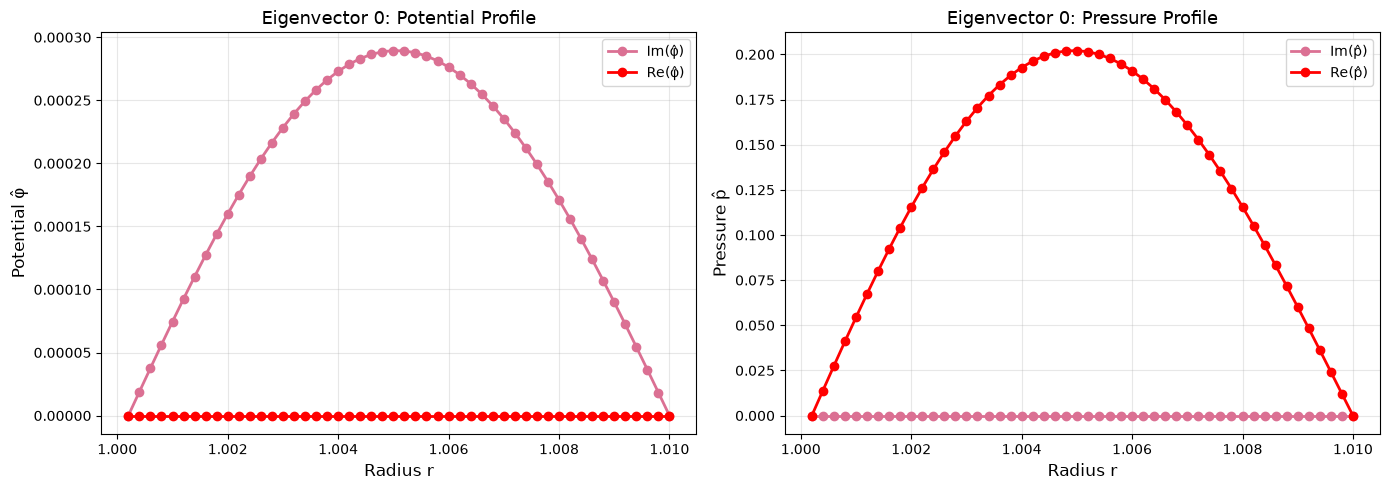

In [129]:
# Eigenvalue for null space vectors are inf, so we only look at the finite eigenvalues
finite_mask = np.isfinite(eigenvalues)
finite_evals = eigenvalues[finite_mask]
finite_indices = np.where(finite_mask)[0]
eigenvector_index = finite_indices[np.argmax(np.real(finite_evals))]
# eigenvector_index = 15

eigenvector = eigenvectors[:, eigenvector_index]
potential = eigenvector[:N]
pressure = eigenvector[N:2*N]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot potential
ax1.plot(r_values, np.imag(potential), 'o-', linewidth=2, label='Im(φ̂)', color='palevioletred')
ax1.plot(r_values, np.real(potential), 'o-',linewidth=2, label='Re(φ̂)', color='red')
ax1.set_xlabel('Radius r', fontsize=12)
ax1.set_ylabel('Potential φ̂', fontsize=12)
ax1.set_title(f'Eigenvector {eigenvector_index}: Potential Profile', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot pressure
ax2.plot(r_values, np.imag(pressure), 'o-', linewidth=2, label='Im(p̂)', color='palevioletred')
ax2.plot(r_values, np.real(pressure), 'o-',linewidth=2, label='Re(p̂)', color='red')
ax2.set_xlabel('Radius r', fontsize=12)
ax2.set_ylabel('Pressure p̂', fontsize=12)
ax2.set_title(f'Eigenvector {eigenvector_index}: Pressure Profile', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

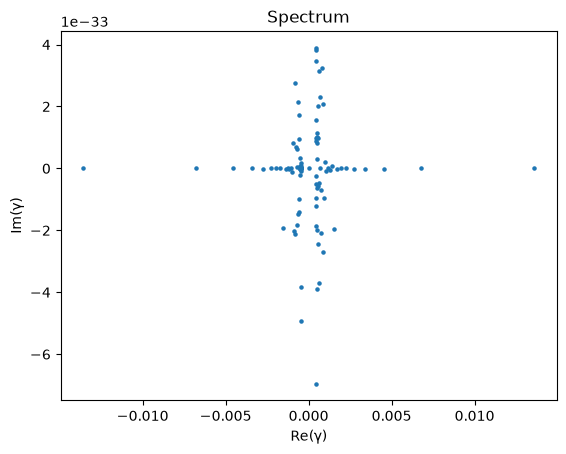

In [130]:
plt.scatter(np.real(finite_evals), np.imag(finite_evals), s=5)
plt.xlabel("Re(γ)"); plt.ylabel("Im(γ)")
plt.title("Spectrum")
plt.show()

In [92]:
np.max(np.real(finite_evals))

np.float64(0.0010190360014878052)

# Testing m scaling

In [135]:
import numpy as np
from scipy.linalg import eig

m_values = np.arange(1, 50)
gamma_values = np.zeros(m_values.shape)

R = 0.1
N = 50    # keep same domain extent r_max = 50
dr = R/N
r_values = np.arange(1, N+1) * dr + 1.

kappa = np.ones(N)

# Equilibrium pressure and potential
L_p = 0.1
p_0  = 1. * np.exp(-(r_values-r_values[0])/L_p)

L_phi = 0.1
phi_0 = 0. * np.exp(-(r_values-r_values[0])/L_phi)

for i in range(len(m_values)):
    m = m_values[i]
    
    A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, kappa, U)

    eigenvalues, eigenvectors = eig(B, A)

    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]

    gamma_values[i] = np.max(np.real(finite_evals))

In [136]:
def gamma(m, kx, kappa, p0, phi0, r, Lp, Lphi):

    ky = m/r
    k2 = kx**2. + ky**2.

    return m / (2*k2) * np.sqrt(8*k2*kappa*p0/(r*Lp) - phi0**2. / (r**2. * Lphi**6))

kx = 2 * np.pi / (2*R)
gamma_analytical = gamma(m_values, kx=kx, kappa=1, p0=p_0.mean(), phi0=phi_0.mean(), r=r_values.mean(), Lp=L_p, Lphi=L_phi)

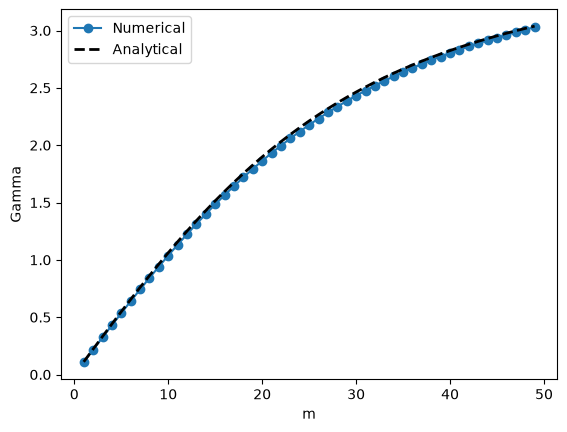

In [137]:
plt.plot(m_values, gamma_values, 'o-', label='Numerical')
plt.plot(m_values, gamma_analytical, 'k--', lw=2, label='Analytical')
plt.xlabel('m')
plt.ylabel('Gamma')
plt.legend()

# Testing k scaling

In [144]:
import numpy as np
from scipy.linalg import eig

k_values = np.arange(1, 100)
gamma_values = np.zeros(k_values.shape)

R = 0.1
N = 50    # keep same domain extent r_max = 50
dr = R/N
r_values = np.arange(1, N+1) * dr + 1.

# Equilibrium pressure and potential
L_p = 0.1
p_0  = 1. * np.exp(-(r_values-r_values[0])/L_p)

L_phi = 0.1
phi_0 = 0. * np.exp(-(r_values-r_values[0])/L_phi)

m = 1

for i in range(len(k_values)):
    kappa = np.ones(N) * k_values[i]
    
    A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, kappa, U)

    eigenvalues, eigenvectors = eig(B, A)

    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]

    gamma_values[i] = np.max(np.real(finite_evals))

In [ ]:
gamma_analytical = gamma(m, kx=kx, kappa=k_values, p0=p_0.mean(), phi0=phi_0.mean(), r=r_values.mean(), Lp=L_p, Lphi=L_phi)

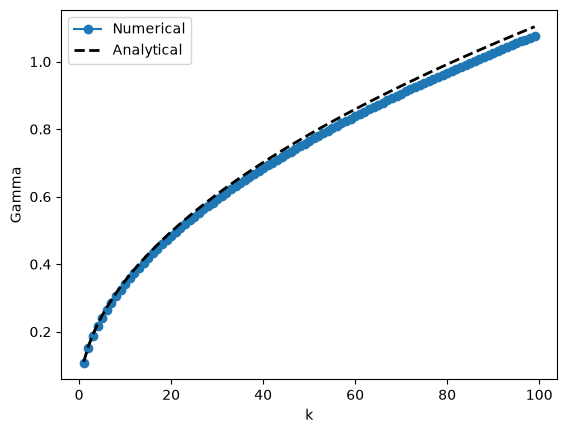

In [146]:
plt.plot(k_values, gamma_values, 'o-', label='Numerical')
plt.plot(k_values, gamma_analytical, 'k--', lw=2, label='Analytical')
plt.xlabel('k')
plt.ylabel('Gamma')
plt.legend()

# Testing L_p scaling

In [147]:
import numpy as np
from scipy.linalg import eig

Lp_values = np.arange(1, 1000, 5) * 0.1
gamma_values = np.zeros(Lp_values.shape)

R = 0.1
N = 50    # keep same domain extent r_max = 50
dr = R/N
r_values = np.arange(1, N+1) * dr + 1.

kappa = np.ones(N)

# Equilibrium pressure and potential
L_p = 0.1
p_0  = 1. * np.exp(-(r_values-r_values[0])/L_p)

L_phi = 0.1
phi_0 = 0. * np.exp(-(r_values-r_values[0])/L_phi)

m = 1

for i in range(len(Lp_values)):
    L_p = np.ones(N) * Lp_values[i]

    p_0  = 1. * np.exp(-(r_values-r_values[0])/L_p)
    
    A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, kappa, U)

    eigenvalues, eigenvectors = eig(B, A)

    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]

    gamma_values[i] = np.max(np.real(finite_evals))

In [ ]:
gamma_analytical = gamma(m, kx=kx, kappa=1, p0=p_0.mean(), phi0=phi_0.mean(), r=r_values.mean(), Lp=Lp_values, Lphi=L_phi)

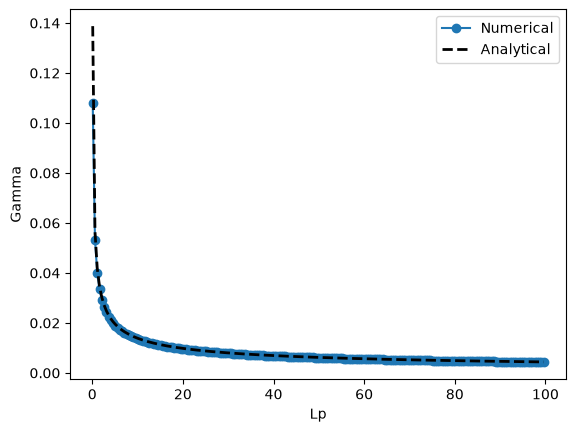

In [151]:
plt.plot(Lp_values, gamma_values, 'o-', label='Numerical')
plt.plot(Lp_values, gamma_analytical, 'k--', lw=2, label='Analytical')
plt.xlabel('Lp')
plt.ylabel('Gamma')
plt.legend()

# Scaling for P0

In [173]:
import numpy as np
from scipy.linalg import eig

P0_values = np.arange(1, 1000, 5)
gamma_values = np.zeros(P0_values.shape)

R = 0.1
N = 50    # keep same domain extent r_max = 50
dr = R/N
r_values = np.arange(1, N+1) * dr + 1.

kappa = np.ones(N)

# Equilibrium pressure and potential
L_p = 0.1

L_phi = 0.1
phi_0 = 0. * np.exp(-(r_values-r_values[0])/L_phi)

m = 1

for i in range(len(P0_values)):
    p_0 = P0_values[i]

    p_0  = p_0 * np.exp(-(r_values-r_values[0])/L_p)
    
    A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, kappa, U)

    eigenvalues, eigenvectors = eig(B, A)

    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]

    gamma_values[i] = np.max(np.real(finite_evals))

In [ ]:
gamma_analytical = gamma(m, kx=kx, kappa=1, p0=(np.outer(P0_values, np.exp(-(r_values - r_values[0]) / L_p)).mean(axis=1)), phi0=phi_0.mean(), r=r_values.mean(), Lp=L_p, Lphi=L_phi)

In [171]:
np.outer(P0_values, np.exp(-(r_values - r_values[0]) / L_p)).mean(axis=1)

array([  0.63846283,   3.83077701,   7.02309118,  10.21540536,
        13.40771953,  16.60003371,  19.79234788,  22.98466206,
        26.17697623,  29.36929041,  32.56160458,  35.75391876,
        38.94623293,  42.13854711,  45.33086128,  48.52317546,
        51.71548963,  54.90780381,  58.10011798,  61.29243216,
        64.48474633,  67.67706051,  70.86937468,  74.06168886,
        77.25400303,  80.44631721,  83.63863138,  86.83094555,
        90.02325973,  93.2155739 ,  96.40788808,  99.60020225,
       102.79251643, 105.9848306 , 109.17714478, 112.36945895,
       115.56177313, 118.7540873 , 121.94640148, 125.13871565,
       128.33102983, 131.523344  , 134.71565818, 137.90797235,
       141.10028653, 144.2926007 , 147.48491488, 150.67722905,
       153.86954323, 157.0618574 , 160.25417158, 163.44648575,
       166.63879992, 169.8311141 , 173.02342827, 176.21574245,
       179.40805662, 182.6003708 , 185.79268497, 188.98499915,
       192.17731332, 195.3696275 , 198.56194167, 201.75

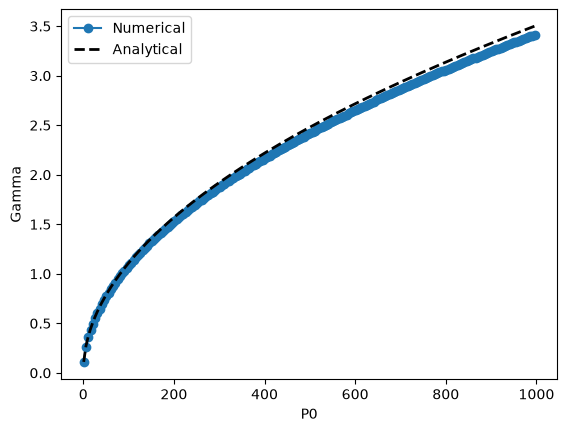

In [175]:
plt.plot(P0_values, gamma_values, 'o-', label='Numerical')
plt.plot(P0_values, gamma_analytical, 'k--', lw=2, label='Analytical')
plt.xlabel('P0')
plt.ylabel('Gamma')
plt.legend()

# Constant-Shear Benchmarks (Bessel analytical model)

For a linearly-sheared potential $\phi_0 = -\tfrac{1}{2}S(r-r_0)^2$ the analytical
growth rate is obtained from the Bessel-function dispersion relation
$I_\alpha(z_0)K_\alpha(z_1) - I_\alpha(z_1)K_\alpha(z_0) = 0$
where $\alpha = \sqrt{\mu^2 + 1/4}$, $\mu = \Omega/S$, and
$\Omega = \sqrt{-2r_0\mathcal{K}P_0'}$.

In [178]:
import numpy as np
import scipy.special as sp
from scipy.optimize import fsolve

def constant_shear_eigen_system(ky, S, alpha, x0, x1, n_re=9, n_im=9):
    """
    Most-unstable growth rate of  D(w)=I_a(z0)K_a(z1)-I_a(z1)K_a(z0)=0,
    z_{0,1}=ky*x_{0,1}+w/S.  2-D complex search -> handles both standing
    (Re w=0, low m) and traveling (Re w!=0, high m) modes.  Returns (gamma, eigs).
    """
    W = x1 - x0; a, b = -W/2, W/2
    Omega = S*np.sqrt(max(alpha**2 - 0.25, 0.0)); kx = np.pi/W
    g_ceiling = abs(ky*Omega)/np.sqrt(kx**2 + ky**2)     # growth ceiling
    Rdop = abs(ky*S*W/2)                                 # max Doppler => |Re w| bound

    def Dc(w):
        z0, z1 = ky*a + w/S, ky*b + w/S
        with np.errstate(over='ignore', invalid='ignore'):     # fsolve probes regions where
            return sp.iv(alpha, z0)*sp.kv(alpha, z1) - sp.iv(alpha, z1)*sp.kv(alpha, z0)

    def g(v):
        d = Dc(v[0] + 1j*v[1])
        return [d.real, d.imag] if np.isfinite(d) else [1e3, 1e3]   # NaN guard (alpha too large)

    found = []
    for wr0 in np.linspace(-1.2*Rdop, 1.2*Rdop, n_re):
        for wi0 in np.linspace(g_ceiling/n_im, g_ceiling, n_im):
            (wr, wi), _, ier, _ = fsolve(g, [wr0, wi0], full_output=True)
            w = wr + 1j*wi
            if (ier == 1 and 1e-4 < wi < 1.001*g_ceiling and abs(wr) < 1.2*Rdop + 1e-2
                    and abs(Dc(w)) < 1e-8 and all(abs(w - z) > 1e-4 for z in found)):
                found.append(w)
    found.sort(key=lambda z: -z.imag)

    return (found[0].imag if found else 0.0), found


# Testing m scaling (constant shear)

In [183]:
import numpy as np
from scipy.linalg import eig

m_values = np.linspace(1, 250, 50)
gamma_values = np.zeros(m_values.shape)

R = 0.01
N = 50
dr = R / N
r_values = np.arange(1, N + 1) * dr + 1.

S = 1.
L_p = 1.
kappa = np.ones(N)
p_0   = 1. * np.exp(-(r_values - r_values[0]) / L_p)
phi_0 = -0.5 * S * (r_values - r_values[0])**2

for i in range(len(m_values)):
    m = m_values[i]
    A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, kappa, U)
    eigenvalues, eigenvectors = eig(B, A)
    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]
    gamma_values[i] = np.max(np.real(finite_evals))


In [184]:
x0 = r_values[0]
x1 = r_values[-1]

Omega = np.sqrt(2 * r_values.mean() * kappa.mean() * p_0.mean() / L_p)
mu = Omega / S
alpha = np.sqrt(mu**2. + 0.25)
print(f"mu = {mu:.3e}")

gamma_analytical = np.zeros(m_values.shape)
for i, m in enumerate(m_values):
    ky = m / r_values.mean()
    gamma_analytical[i], _ = constant_shear_eigen_system(ky, S, alpha, x0, x1)


mu = 1.414e+00


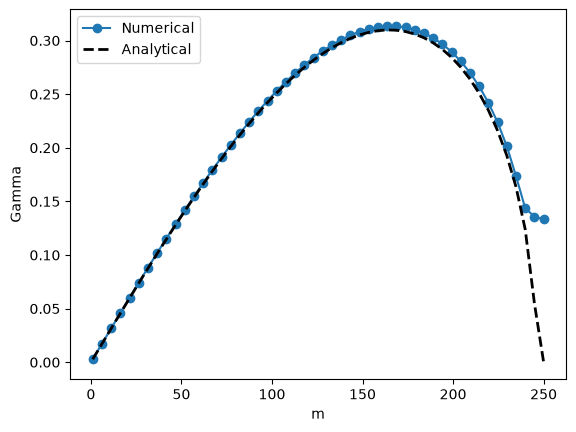

In [185]:
plt.plot(m_values, gamma_values, 'o-', label='Numerical')
plt.plot(m_values, gamma_analytical, 'k--', lw=2, label='Analytical')
plt.xlabel('m')
plt.ylabel('Gamma')
plt.legend()


# Testing k scaling (constant shear)

In [195]:
import numpy as np
from scipy.linalg import eig

k_values = np.linspace(0.1, 200, 40)
gamma_values = np.zeros(k_values.shape)

R = 0.01
N = 50
dr = R / N
r_values = np.arange(1, N + 1) * dr + 1.

S = 1.
L_p = 1.
p_0  = 1. * np.exp(-(r_values - r_values[0]) / L_p)
phi_0 = -0.5 * S * (r_values - r_values[0])**2

m = 1

for i in range(len(k_values)):
    kappa = np.ones(N) * k_values[i]
    A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, kappa, U)
    eigenvalues, eigenvectors = eig(B, A)
    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]
    gamma_values[i] = np.max(np.real(finite_evals))


In [196]:
x0 = r_values[0]
x1 = r_values[-1]
ky = m / r_values.mean()

gamma_analytical = np.zeros(k_values.shape)
for i, kap in enumerate(k_values):
    Omega = np.sqrt(2 * r_values.mean() * kap * p_0.mean() / L_p)
    mu = Omega / S
    alpha = np.sqrt(mu**2. + 0.25)
    gamma_analytical[i], _ = constant_shear_eigen_system(ky, S, alpha, x0, x1)


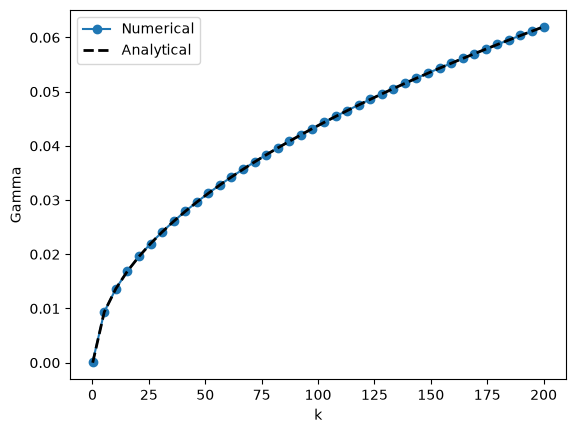

In [197]:
plt.plot(k_values, gamma_values, 'o-', label='Numerical')
plt.plot(k_values, gamma_analytical, 'k--', lw=2, label='Analytical')
plt.xlabel('k')
plt.ylabel('Gamma')
plt.legend()


# Testing L_p scaling (constant shear)

In [198]:
import numpy as np
from scipy.linalg import eig

Lp_values = np.linspace(0.1, 200, 40)
gamma_values = np.zeros(Lp_values.shape)

R = 0.01
N = 50
dr = R / N
r_values = np.arange(1, N + 1) * dr + 1.

S = 1.
kappa = np.ones(N)
phi_0 = -0.5 * S * (r_values - r_values[0])**2

m = 1

for i in range(len(Lp_values)):
    L_p = Lp_values[i]
    p_0  = 1. * np.exp(-(r_values - r_values[0]) / L_p)
    A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, kappa, U)
    eigenvalues, eigenvectors = eig(B, A)
    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]
    gamma_values[i] = np.max(np.real(finite_evals))


In [199]:
x0 = r_values[0]
x1 = r_values[-1]
ky = m / r_values.mean()

gamma_analytical = np.zeros(Lp_values.shape)
for i, L_p in enumerate(Lp_values):
    p_0 = 1. * np.exp(-(r_values - r_values[0]) / L_p)
    Omega = np.sqrt(2 * r_values.mean() * kappa.mean() * p_0.mean() / L_p)
    mu = Omega / S
    alpha = np.sqrt(mu**2. + 0.25)
    gamma_analytical[i], _ = constant_shear_eigen_system(ky, S, alpha, x0, x1)


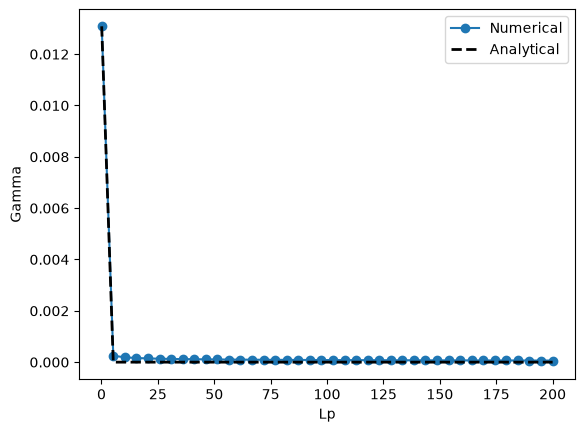

In [200]:
plt.plot(Lp_values, gamma_values, 'o-', label='Numerical')
plt.plot(Lp_values, gamma_analytical, 'k--', lw=2, label='Analytical')
plt.xlabel('Lp')
plt.ylabel('Gamma')
plt.legend()


# Scaling for P0 (constant shear)

In [204]:
import numpy as np
from scipy.linalg import eig

P0_values = np.linspace(0.1, 1000, 40)
gamma_values = np.zeros(P0_values.shape)

R = 0.01
N = 50
dr = R / N
r_values = np.arange(1, N + 1) * dr + 1.

S = 1.
L_p = 1.
kappa = np.ones(N)
phi_0 = -0.5 * S * (r_values - r_values[0])**2

m = 1

for i in range(len(P0_values)):
    p_0 = P0_values[i] * np.exp(-(r_values - r_values[0]) / L_p)
    A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, kappa, U)
    eigenvalues, eigenvectors = eig(B, A)
    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]
    gamma_values[i] = np.max(np.real(finite_evals))


In [206]:
x0 = r_values[0]
x1 = r_values[-1]
ky = m / r_values.mean()

gamma_analytical = np.zeros(P0_values.shape)
for i, P0 in enumerate(P0_values):
    p_0 = P0 * np.exp(-(r_values - r_values[0]) / L_p)
    Omega = np.sqrt(2 * r_values.mean() * kappa.mean() * p_0.mean() / L_p)
    mu = Omega / S
    alpha = np.sqrt(mu**2. + 0.25)
    gamma_analytical[i], _ = constant_shear_eigen_system(ky, S, alpha, x0, x1)


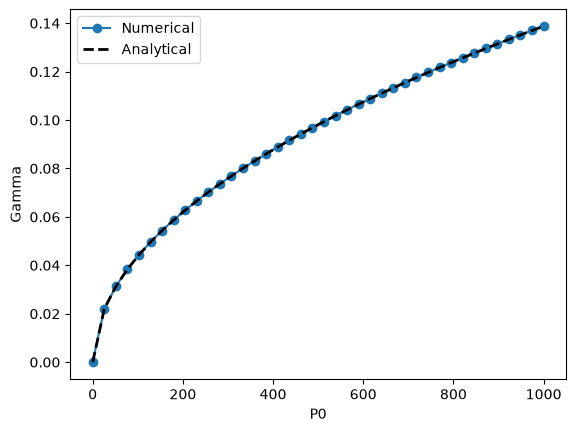

In [207]:
plt.plot(P0_values, gamma_values, 'o-', label='Numerical')
plt.plot(P0_values, gamma_analytical, 'k--', lw=2, label='Analytical')
plt.xlabel('P0')
plt.ylabel('Gamma')
plt.legend()


# Testing S scaling (constant shear)

In [ ]:
import numpy as np
from scipy.linalg import eig

S_values = np.linspace(0.1, 10, 40)
gamma_values = np.zeros(S_values.shape)

R = 0.1
N = 50
dr = R / N
r_values = np.arange(1, N + 1) * dr + 1.

L_p = 1.
kappa = np.ones(N)
p_0  = 1. * np.exp(-(r_values - r_values[0]) / L_p)

m = 1

for i in range(len(S_values)):
    S = S_values[i]
    phi_0 = -0.5 * S * (r_values - r_values[0])**2
    A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, kappa, U)
    eigenvalues, eigenvectors = eig(B, A)
    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]
    gamma_values[i] = np.max(np.real(finite_evals))


In [ ]:
x0 = r_values[0]
x1 = r_values[-1]
ky = m / r_values.mean()

gamma_analytical = np.zeros(S_values.shape)
for i, S in enumerate(S_values):
    Omega = np.sqrt(2 * r_values.mean() * kappa.mean() * p_0.mean() / L_p)
    mu = Omega / S
    alpha = np.sqrt(mu**2. + 0.25)
    gamma_analytical[i], _ = constant_shear_eigen_system(ky, S, alpha, x0, x1)


In [ ]:
plt.plot(S_values, gamma_values, 'o-', label='Numerical')
plt.plot(S_values, gamma_analytical, 'k--', lw=2, label='Analytical')
plt.xlabel('S')
plt.ylabel('Gamma')
plt.legend()
